# 1. Queda Livre: Modelagem Matemática e Implementação Computacional

Este notebook segue o roteiro proposto para o trabalho prático de modelagem matemática da Queda Livre, unindo teoria, programação e análise de resultados. Cada etapa é explicada em detalhes, com células Markdown e código Python, além de salvar os dados e gráficos gerados.

## 1.1 Implementação Básica do Modelo de Queda Livre

Neste passo, vamos implementar o modelo discreto da queda livre usando o método de Euler. O objetivo é calcular, passo a passo, a posição e a velocidade de uma pedra até ela atingir o solo.

### Entradas do Modelo

- **Altura inicial** $H$ (ex: 100 m)
- **Velocidade inicial** $V$ (ex: 0 m/s)
- **Gravidade** $g$ (9,81 m/s²)
- **Passo de tempo** $\Delta t$ (ex: 0,1 s, etc)

> **Observação:** Todos os dados de entrada e saída serão salvos em arquivos `.txt` na pasta `src/dados` e os gráficos gerados em `.png` na pasta `src/graficos`. Isso facilita a organização e reutilização dos resultados.


In [266]:
# Criação das pastas para dados e gráficos (executar uma vez)
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Caminho absoluto da pasta onde está o notebook (compatível com Jupyter)
base_dir = Path().resolve()
dados_dir = base_dir / 'dados'
graficos_dir = base_dir / 'graficos'
dados_dir.mkdir(exist_ok=True)
graficos_dir.mkdir(exist_ok=True)
print(f'Pastas criadas ou já existentes:\n{dados_dir}\n{graficos_dir}')


Pastas criadas ou já existentes:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\dados
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos


In [267]:
# Função para simular a queda livre usando o método de Euler
# Agora retorna DataFrame padronizado

def simula_queda_livre(H, V, g, dt):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt)
        a.append(-g)
    if x[-1] < 0:
        x[-1] = 0
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

In [268]:
# Função para salvar os resultados da simulação em um arquivo CSV usando pandas
# Agora usa o DataFrame padronizado

def salvar_resultado(df, dados_dir, nome_arquivo):
    saida_csv = os.path.join(dados_dir, nome_arquivo)
    df.to_csv(saida_csv, index=False, float_format='%.4f')

## 1.2. Apresentação dos Gráficos: Posição, Velocidade e Aceleração em função do Tempo

Nesta seção, apresentamos os gráficos que ilustram o comportamento da queda livre de uma partícula, conforme o modelo matemático e computacional desenvolvido. Os gráficos mostram:

- **Posição x Tempo:** A altura da partícula ao longo do tempo, evidenciando a trajetória de queda.
- **Velocidade x Tempo:** A evolução da velocidade (em módulo) ao longo do tempo, destacando o aumento da rapidez durante a queda.
- **Aceleração x Tempo:** A aceleração constante da gravidade, representada por uma linha horizontal.

Esses gráficos permitem visualizar claramente as características do movimento sob as suposições do modelo simplificado (partícula, sem resistência do ar), e servem como base para análises comparativas e discussões sobre refinamentos do modelo.


In [269]:
# Funções separadas para plotar cada tipo de gráfico, recebendo também o nome do arquivo
import matplotlib.pyplot as plt
import os

def plotar_grafico_posicao_tempo(resultados, dt_list, graficos_dir, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        x = resultados[dt]['x']
        plt.plot(t, x, label=f'dt={dt}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title('Posição x Tempo (Queda Livre)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_velocidade_tempo(resultados, dt_list, graficos_dir, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        v = resultados[dt]['v']
        v_abs = [abs(vi) for vi in v]
        plt.plot(t, v_abs, label=f'dt={dt}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title('Velocidade x Tempo (Queda Livre)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_aceleracao_tempo(resultados, dt_list, graficos_dir, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        g = -9.81
        aceleracao = [g for _ in t]
        plt.plot(t, aceleracao, label=f'dt={dt}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title('Aceleração x Tempo (Queda Livre)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

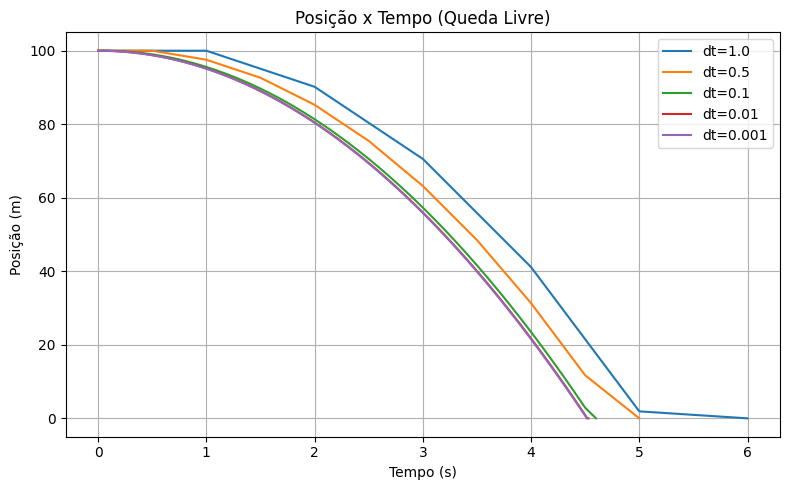

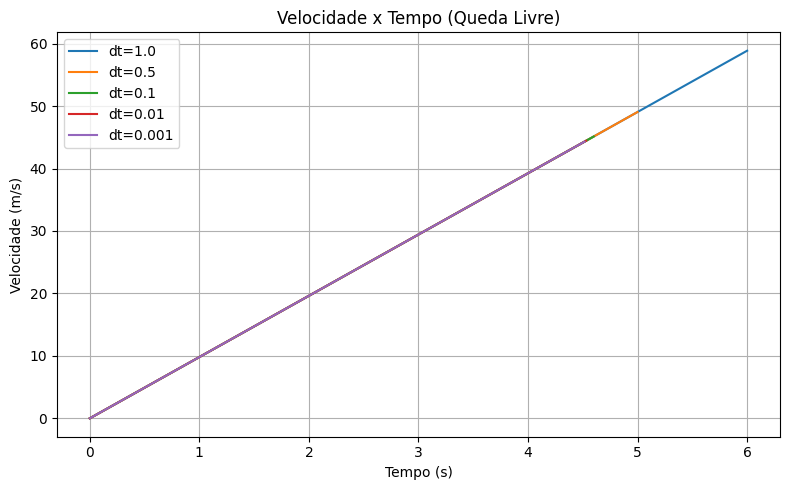

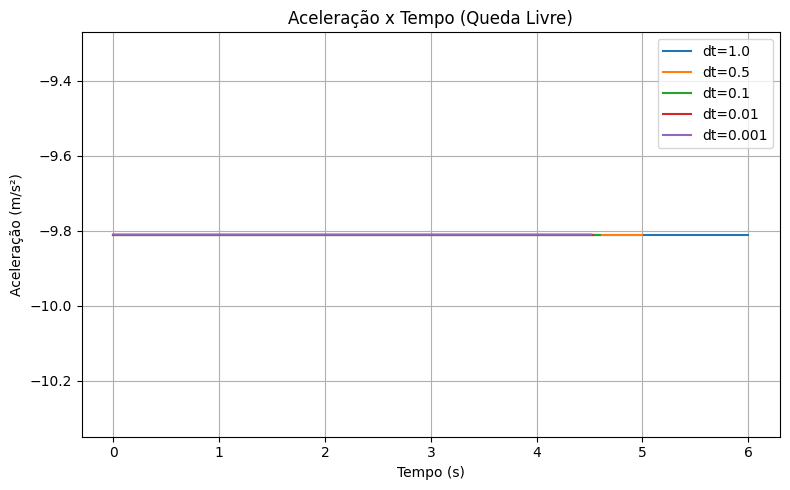

In [270]:
# Leitura dos resultados salvos em CSV para cada dt usando pandas e plotagem dos gráficos

# Definindo os parâmetros iniciais
H = 100.0 # altura inicial (m)
V = 0.0   # velocidade inicial (m/s)
g = 9.81  # gravidade (m/s^2)

dt_list = [1.0, 0.5, 0.1, 0.01, 0.001]  # lista de passos de tempo

# Simulação para cada dt em dt_list e salvando os resultados
resultados = {}
for dt in dt_list:
    df = simula_queda_livre(H, V, g, dt)
    resultados[dt] = df
    # Salvar cada simulação usando a função padronizada
    nome_arquivo = f'saida_queda_livre_dt_{str(dt).replace(".", "_")}.csv'
    salvar_resultado(df, dados_dir, nome_arquivo)

resultados_csv = {}
for dt in dt_list:
    nome_arquivo = f'saida_queda_livre_dt_{str(dt).replace(".","_")}.csv'
    caminho_arquivo = dados_dir / nome_arquivo
    # print(f'\nConteúdo de {nome_arquivo}:')
    df = pd.read_csv(caminho_arquivo)
    # Armazena os dados lidos para plotagem
    resultados_csv[dt] = {
        't': df['tempo'].tolist(),
        'x': df['posicao'].tolist(),
        'v': df['velocidade'].tolist()
    }

# Chama as funções separadas para plotar e salvar cada gráfico
plotar_grafico_posicao_tempo(resultados_csv, dt_list, graficos_dir, 'grafico_posicao_tempo_multidt.png')
plotar_grafico_velocidade_tempo(resultados_csv, dt_list, graficos_dir, 'grafico_velocidade_tempo_multidt.png')
plotar_grafico_aceleracao_tempo(resultados_csv, dt_list, graficos_dir, 'grafico_aceleracao_tempo_multidt.png')

## 1.3. Discussão: Implicações de Considerar um Corpo Rígido em Queda Livre

Ao considerar um **corpo rígido** em queda livre, a modelagem se torna mais realista e complexa. As principais implicações e alterações são:

- **Resistência do ar:** O corpo rígido possui área, forma e orientação, tornando a resistência do ar relevante. O modelo passa a incluir um termo de arrasto, geralmente proporcional ao quadrado da velocidade ($F_{ar} = -k v^2$), além de depender do coeficiente de arrasto, área frontal e densidade do ar.
- **Velocidade terminal:** Diferente do modelo de partícula, o corpo rígido atinge uma velocidade máxima (velocidade terminal), onde a força de resistência do ar equilibra a força da gravidade.
- **Rotação:** O corpo rígido pode girar durante a queda, alterando a área de contato com o ar e, consequentemente, a resistência. Em casos avançados, seria necessário modelar o momento angular e a dinâmica de rotação.
- **Equações de movimento:** A aceleração deixa de ser constante, pois depende da velocidade e das características do corpo. O sistema de equações diferenciais pode exigir métodos numéricos mais sofisticados.
- **Resultados e gráficos:** A curva de velocidade x tempo deixa de ser uma reta e passa a ser uma curva que se estabiliza. A posição x tempo também se modifica, refletindo a influência da resistência.

Essas alterações tornam o modelo mais próximo da realidade, mas exigem mais parâmetros e maior cuidado na implementação. A discussão desses pontos é fundamental para justificar as limitações do modelo simplificado e propor caminhos para refinamento e análise de casos reais.


Discussão: Modelagem de Corpo Rígido em Queda Livre

Se considerarmos um corpo rígido em queda livre, algumas implicações e possíveis alterações surgem na modelagem:

**1. Resistência do ar e formato:**
- Um corpo rígido pode ter diferentes formatos (esfera, cilindro, placa), o que altera o coeficiente de arrasto ($C_d$) e a área de contato ($A$) com o ar.
- A equação da força de resistência pode passar de $F_r = c v$ (linear) para $F_r = \frac{1}{2} C_d \rho A v^2$ (quadrática), tornando o modelo mais realista para velocidades maiores.

**2. Rotação e estabilidade:**
- Corpos rígidos podem girar durante a queda, mudando a área de contato e o arrasto ao longo do tempo.
- A rotação pode causar instabilidades, como "efeito folha", dificultando a previsão do movimento.

**3. Terminalidade da velocidade:**
- Com resistência quadrática, a velocidade terminal depende do formato, massa e área do corpo.
- A modelagem deve incluir parâmetros como $C_d$, $A$, $\rho$ (densidade do ar) e massa ($m$).

**4. Simulação numérica:**
- O modelo pode exigir sistemas de equações diferenciais para posição, velocidade e rotação.
- A simulação pode precisar de métodos numéricos mais avançados (Runge-Kutta, por exemplo).

**5. Aplicações práticas:**
- Modelar corpos rígidos é essencial para entender a queda de objetos reais (parafusos, folhas, bolas, etc.), prever impactos e projetar experimentos.

**Exemplo de alteração na equação de movimento:**

$$
\frac{dv}{dt} = g - \frac{1}{2} \frac{C_d \rho A}{m} v^2
$$

Essa equação pode ser resolvida numericamente para obter a posição e velocidade ao longo do tempo.

**Conclusão:**
A modelagem de um corpo rígido em queda livre é mais complexa, mas permite resultados mais próximos da realidade, especialmente quando há resistência do ar significativa, rotação ou formatos não esféricos. Isso amplia as possibilidades de análise e aplicação em contextos reais.

In [271]:
# Modelagem de corpo rígido em queda livre com resistência quadrática
import numpy as np
import pandas as pd

def simula_queda_livre_quadratica(H, m, Cd, A, rho, dt, t_max):
    """
    Simula a queda livre de um corpo rígido com resistência quadrática.
    Parâmetros:
        H: altura inicial (m)
        m: massa (kg)
        Cd: coeficiente de arrasto
        A: área de contato (m²)
        rho: densidade do ar (kg/m³)
        dt: passo de tempo (s)
        t_max: tempo máximo de simulação (s)
    Retorna:
        DataFrame com tempo, posição, velocidade e aceleração
    """
    g = 9.81
    n = int(t_max / dt) + 1
    t = np.linspace(0, t_max, n)
    x = np.zeros(n)
    v = np.zeros(n)
    a = np.zeros(n)
    x[0] = H
    v[0] = 0
    for i in range(1, n):
        Fr = 0.5 * Cd * rho * A * v[i-1]**2
        a[i-1] = g - Fr / m
        v[i] = v[i-1] + a[i-1] * dt
        x[i] = x[i-1] - v[i] * dt
        if x[i] <= 0:
            x[i] = 0
            v[i] = 0
            a[i] = 0
            t = t[:i+1]
            x = x[:i+1]
            v = v[:i+1]
            a = a[:i+1]
            break
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

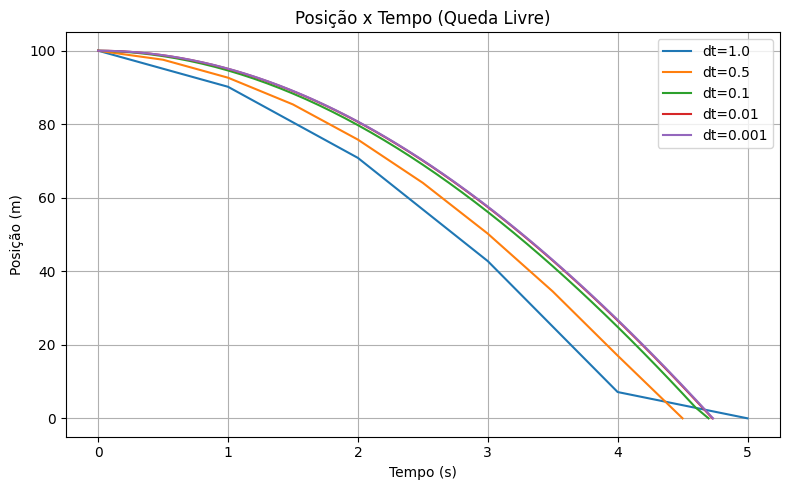

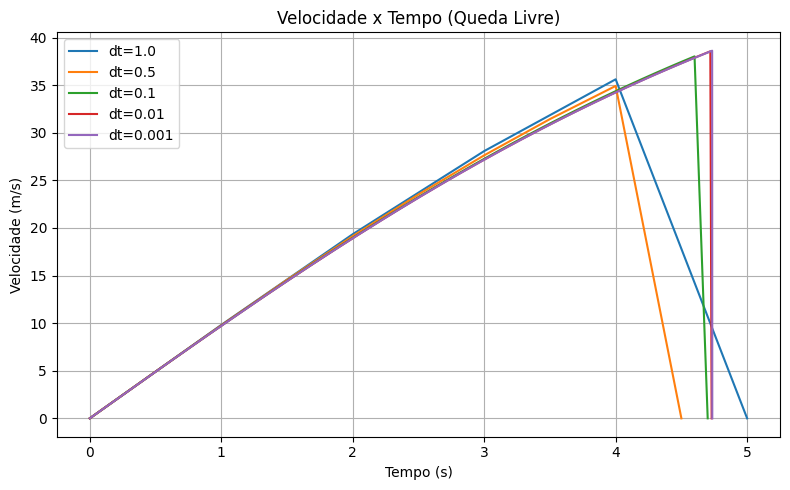

In [272]:
# Simulação para lista de dt (passos de tempo) e salvando na pasta correta para o caso quadrático (corpo rígido com resistência do ar quadrática)
H = 100         # altura inicial (m)
m = 1.0         # massa (kg)
Cd = 0.47       # coeficiente de arrasto (esfera)
A = 0.01        # área de contato (m²)
rho = 1.225     # densidade do ar (kg/m³)
t_max = 20      # tempo máximo de simulação (s)

# Simulação e salvamento dos resultados para cada dt
for dt in dt_list:
    df_quadratica = simula_queda_livre_quadratica(H, m, Cd, A, rho, dt, t_max)
    nome_arquivo = f'saida_queda_livre_quadratica_dt_{str(dt).replace(".", "_")}.csv'
    salvar_resultado(df_quadratica, dados_dir, nome_arquivo)

# Leitura dos resultados salvos em CSV para cada dt (corpo rígido com resistência quadrática)
resultados_csv_quadratica = {}
for dt in dt_list:
    nome_arquivo = f'saida_queda_livre_quadratica_dt_{str(dt).replace(".", "_")}.csv'
    caminho_arquivo = dados_dir / nome_arquivo
    if not caminho_arquivo.exists():
        print(f'Aviso: arquivo {nome_arquivo} não encontrado, pulando...')
        continue
    try:
        df = pd.read_csv(caminho_arquivo)
        resultados_csv_quadratica[dt] = {
            't': df['tempo'].tolist(),
            'x': df['posicao'].tolist(),
            'v': df['velocidade'].tolist()
        }
    except Exception as e:
        print(f'Erro ao ler {nome_arquivo}: {e}')

# Plotando os gráficos usando as funções já criadas
plotar_grafico_posicao_tempo(resultados_csv_quadratica, dt_list, graficos_dir, 'grafico_posicao_tempo_quadratica_multidt.png')
plotar_grafico_velocidade_tempo(resultados_csv_quadratica, dt_list, graficos_dir, 'grafico_velocidade_tempo_quadratica_multidt.png')

## 1.4. Resistência do Ar (Bônus)

Agora, vamos refinar o modelo incluindo a resistência do ar proporcional à velocidade. O coeficiente de arrasto $c$ será escolhido para ilustrar o efeito.

In [273]:
# Função para simular queda livre com resistência do ar proporcional à velocidade
# Agora retorna DataFrame padronizado

def simula_queda_livre_resistencia(H, V, g, dt, c):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g + c*v[-1]]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt + c*v[-1]*dt)
        a.append(-g + c*v[-1])
    if x[-1] < 0:
        x[-1] = 0
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

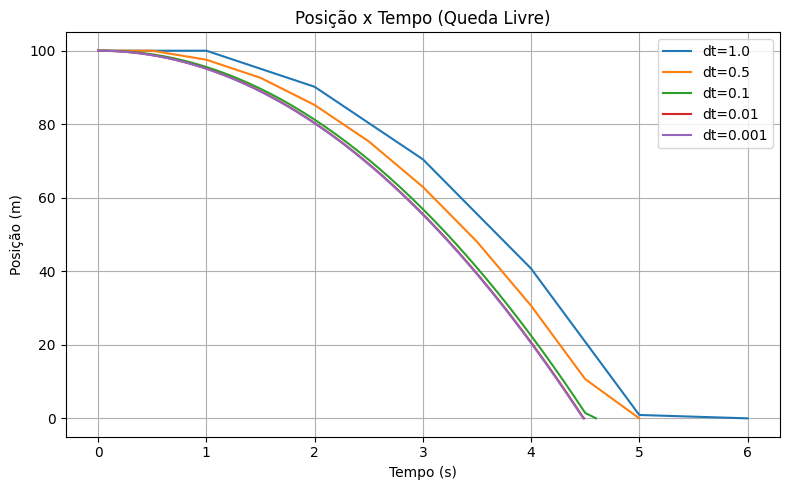

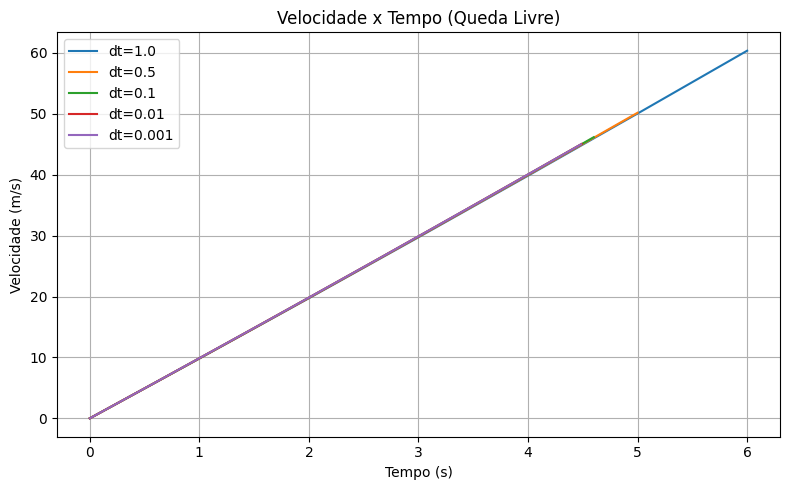

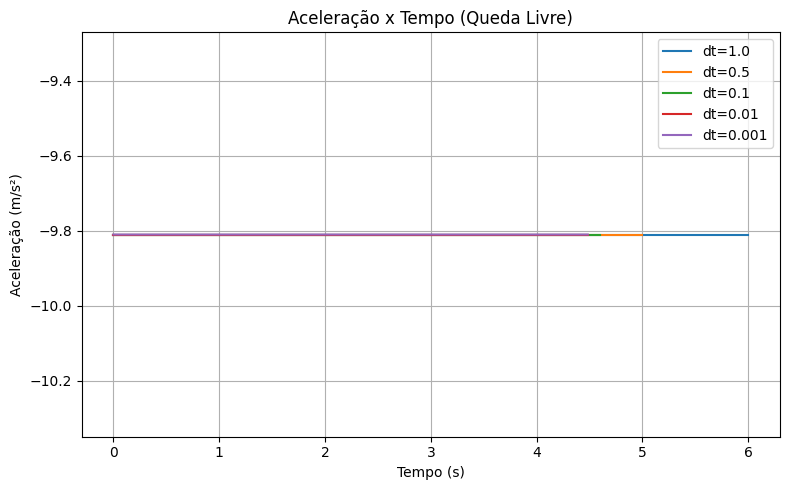

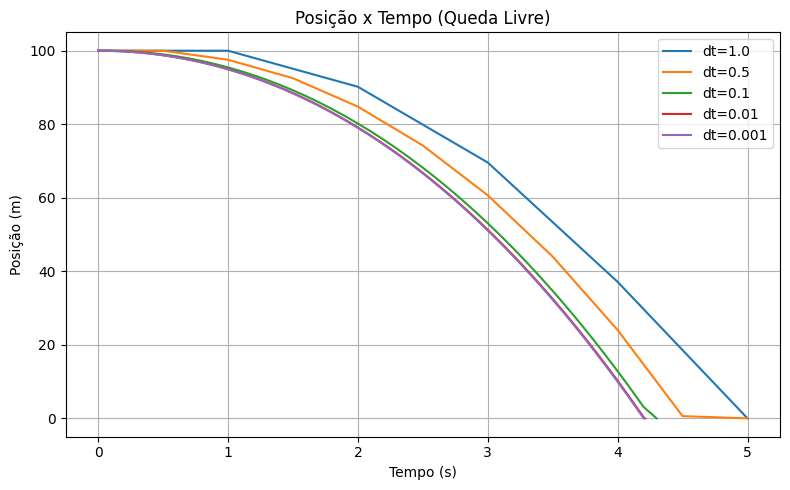

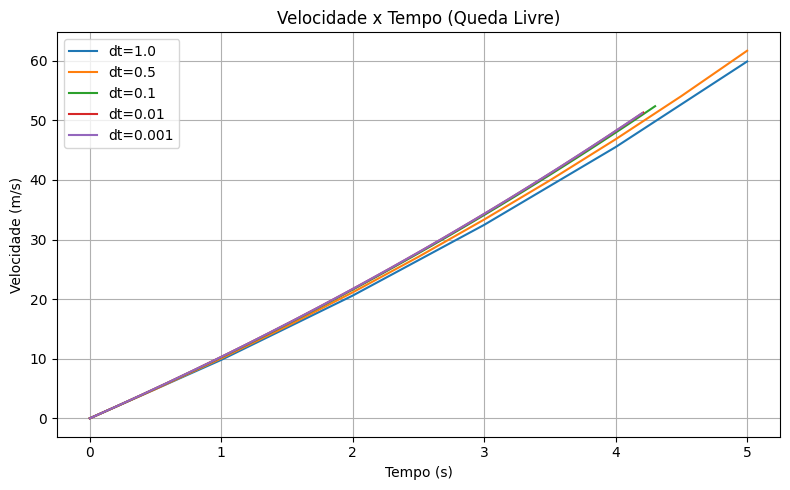

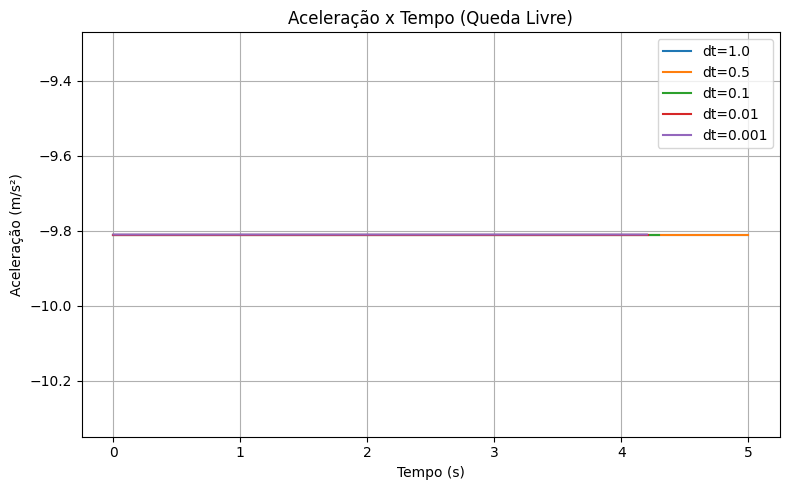

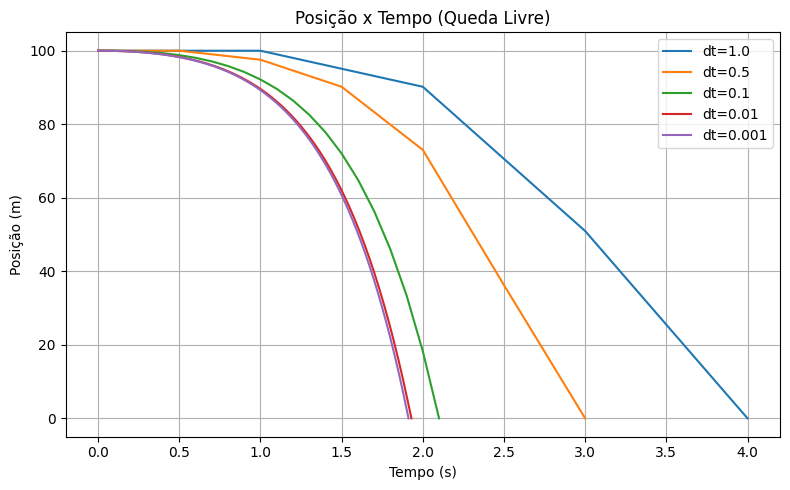

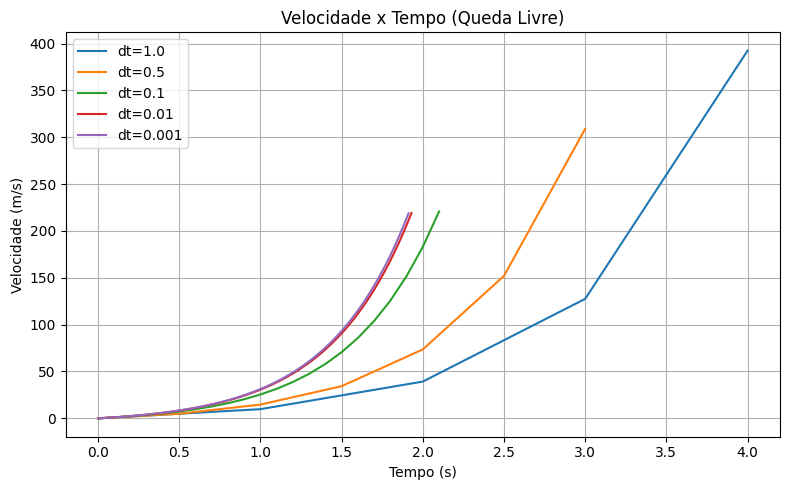

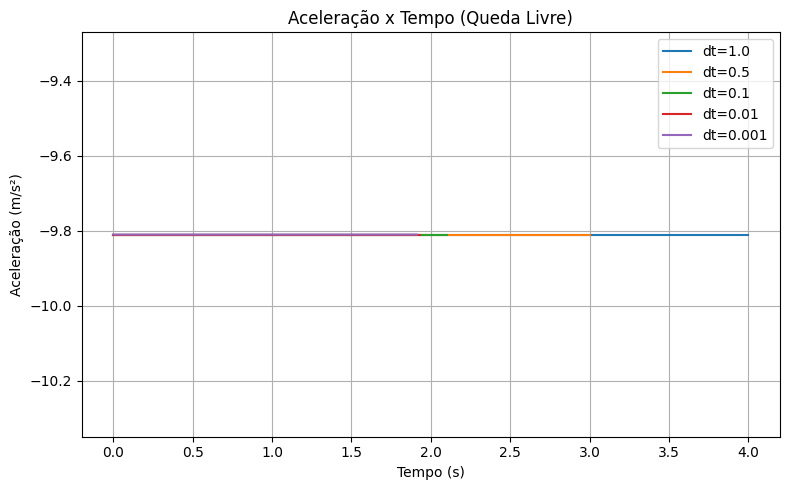

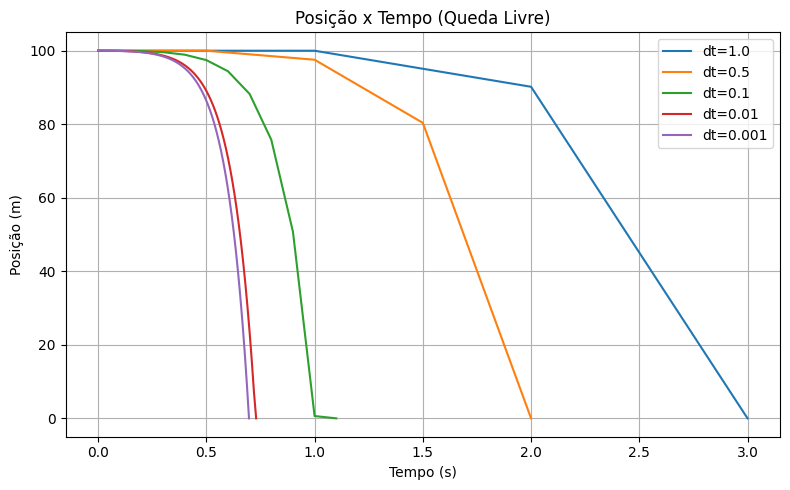

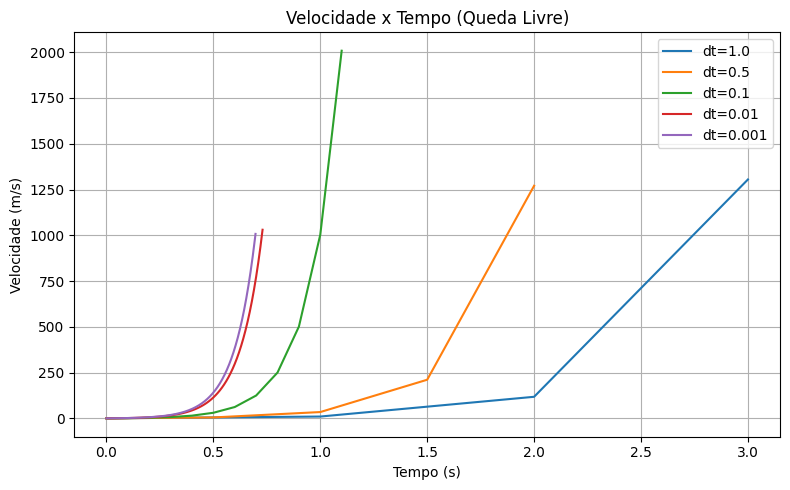

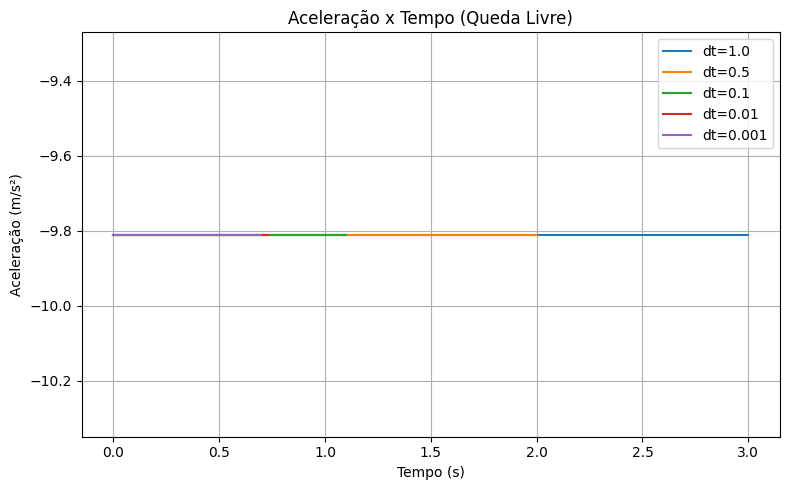

In [274]:
# Simulação para lista de dt (passos de tempo) e lista de c (coeficiente de resistência do ar) para o caso com resistência do ar (linear)

c_list = [0.01, 0.1, 2, 10]  # valores de exemplo para o coeficiente de resistência do ar

for c in c_list:
    # Simulação e salvamento dos resultados para cada dt e cada c
    for dt in dt_list:
        df_resistencia = simula_queda_livre_resistencia(H, V, g, dt, c)
        nome_arquivo = f'saida_queda_livre_resistencia_dt_{str(dt).replace(".", "_")}_c_{str(c).replace(".", "_")}.csv'
        salvar_resultado(df_resistencia, dados_dir, nome_arquivo)

    # Leitura dos resultados salvos em CSV para cada dt (com resistência do ar para este c)
    resultados_csv_resistencia = {}
    for dt in dt_list:
        nome_arquivo = f'saida_queda_livre_resistencia_dt_{str(dt).replace(".", "_")}_c_{str(c).replace(".", "_")}.csv'
        caminho_arquivo = dados_dir / nome_arquivo
        df = pd.read_csv(caminho_arquivo)
        resultados_csv_resistencia[dt] = {
            't': df['tempo'].tolist(),
            'x': df['posicao'].tolist(),
            'v': df['velocidade'].tolist()
        }

    # Plotando os gráficos usando as funções já criadas para cada c
    plotar_grafico_posicao_tempo(resultados_csv_resistencia, dt_list, graficos_dir, f'grafico_posicao_tempo_resistencia_c_{str(c).replace(",","_")}.png')
    plotar_grafico_velocidade_tempo(resultados_csv_resistencia, dt_list, graficos_dir, f'grafico_velocidade_tempo_resistencia_c_{str(c).replace(",","_")}.png')
    plotar_grafico_aceleracao_tempo(resultados_csv_resistencia, dt_list, graficos_dir, f'grafico_aceleracao_tempo_resistencia_c_{str(c).replace(",","_")}.png')


### 1.5 Estudo da Acurácia no Valor Final da Velocidade

Agora vamos analisar a acurácia do valor final da velocidade ($v_{final}$) obtido numericamente para diferentes passos de tempo ($\Delta t$), comparando com o valor analítico esperado para cada caso (com e sem resistência do ar).

In [275]:
# Função para calcular o valor analítico da velocidade final
import numpy as np

def vfinal_analitico_sem_resistencia(V, g, t):
    return V - g * t

def vfinal_analitico_com_resistencia(V, g, c, t):
    return (V + g/c) * np.exp(c * t) - g/c

# Função para calcular erro relativo
def erro_relativo(v_num, v_ana):
    return abs((v_num - v_ana) / v_ana) if v_ana != 0 else np.nan

# Função para simular, calcular analítico e erro para uma lista de dt
def acuracia_vfinal(simulador, v_analitico_func, H, V, g, dt_list, c=None):
    v_finais = []
    t_finais = []
    v_analiticos = []
    erros = []
    for dt in dt_list:
        if c is not None:
            df = simulador(H, V, g, dt, c)
            t = df['tempo']
            v = df['velocidade']
            v_ana = v_analitico_func(V, g, c, t.iloc[-1])
        else:
            df = simulador(H, V, g, dt)
            t = df['tempo']
            v = df['velocidade']
            v_ana = v_analitico_func(V, g, t.iloc[-1])
        v_finais.append(v.iloc[-1])
        t_finais.append(t.iloc[-1])
        v_analiticos.append(v_ana)
        erros.append(erro_relativo(v.iloc[-1], v_ana))
    return v_finais, t_finais, v_analiticos, erros

# Função para salvar resultados em CSV
def salvar_acuracia_csv(dt_list, v_finais, t_finais, v_analiticos, erros, dados_dir, nome_arquivo):
    import pandas as pd
    df = pd.DataFrame({
        'dt': dt_list,
        'tempo_final': t_finais,
        'v_final_num': v_finais,
        'v_final_analitico': v_analiticos,
        'erro_relativo': erros
    })
    df.to_csv(dados_dir / nome_arquivo, index=False, float_format='%.6f')
    return df

# Exemplo de uso para ambos os casos:
# Sem resistência
dt = 0.01
dt_list = (np.arange(0.001, 1.001, dt)).tolist()
# dt_list = [1.0, 0.5, 0.1, 0.01, 0.001]
vf_sem, tf_sem, van_sem, err_sem = acuracia_vfinal(simula_queda_livre, vfinal_analitico_sem_resistencia, H, V, g, dt_list)
df_sem = salvar_acuracia_csv(dt_list, vf_sem, tf_sem, van_sem, err_sem, dados_dir, 'acuracia_sem_resistencia.csv')

display(df_sem)

# Com resistência para vários valores de c
c_list = [0.01, 0.1, 2, 10]
acuracias_com_resistencia = {}
for c in c_list:
    vf_com, tf_com, van_com, err_com = acuracia_vfinal(simula_queda_livre_resistencia, vfinal_analitico_com_resistencia, H, V, g, dt_list, c=c)
    nome_arquivo = f'acuracia_com_resistencia_c_{str(c).replace(".", "_")}.csv'
    df_com = salvar_acuracia_csv(dt_list, vf_com, tf_com, van_com, err_com, dados_dir, nome_arquivo)
    acuracias_com_resistencia[c] = df_com
    print(f"Acurácia para c = {c}:")
    display(df_com)


,dt,tempo_final,v_final_num,v_final_analitico,erro_relativo
0,0.001,4.516,-44.30196,-44.30196,1.384134e-13
1,0.011,4.521,-44.35101,-44.35101,1.009316e-14
2,0.021,4.536,-44.49816,-44.49816,1.596791e-16
3,0.031,4.557,-44.70417,-44.70417,2.384149e-15
4,0.041,4.551,-44.64531,-44.64531,2.228140e-15
...,...,...,...,...,...
95,0.951,5.706,-55.97586,-55.97586,1.269374e-16
96,0.961,5.766,-56.56446,-56.56446,3.768494e-16
97,0.971,5.826,-57.15306,-57.15306,1.243228e-16
98,0.981,5.886,-57.74166,-57.74166,0.000000e+00


Acurácia para c = 0.01:


,dt,tempo_final,v_final_num,v_final_analitico,erro_relativo
0,0.001,4.483,-44.978669,44.978899,1.999995
1,0.011,4.488,-45.027667,45.030200,1.999944
2,0.021,4.494,-45.086922,45.091763,1.999893
3,0.031,4.526,-45.412966,45.420165,1.999841
4,0.041,4.510,-45.246465,45.255951,1.999790
...,...,...,...,...,...
95,0.951,5.706,-57.323682,57.603664,1.995140
96,0.961,5.766,-57.940960,58.227014,1.995087
97,0.971,5.826,-58.558544,58.850737,1.995035
98,0.981,5.886,-59.176434,59.474834,1.994983


Acurácia para c = 0.1:


,dt,tempo_final,v_final_num,v_final_analitico,erro_relativo
0,0.001,4.201,-51.216224,51.219360,1.999939
1,0.011,4.213,-51.364039,51.398651,1.999327
2,0.021,4.221,-51.452093,51.518297,1.998715
3,0.031,4.247,-51.809299,51.907811,1.998102
4,0.041,4.264,-52.032108,52.163041,1.997490
...,...,...,...,...,...
95,0.951,5.706,-71.096619,75.471109,1.942038
96,0.961,5.766,-72.025758,76.515666,1.941320
97,0.971,4.855,-57.819374,61.311254,1.943047
98,0.981,4.905,-58.531268,62.110306,1.942376


Acurácia para c = 2:


,dt,tempo_final,v_final_num,v_final_analitico,erro_relativo
0,0.001,1.912,-218.824153,219.680188,1.996103
1,0.011,1.936,-221.036846,230.723189,1.958017
2,0.021,1.953,-220.174984,238.872297,1.921727
3,0.031,1.984,-225.561647,254.464865,1.886416
4,0.041,2.009,-228.319832,267.763042,1.852694
...,...,...,...,...,...
95,0.951,3.804,-342.974345,9874.969547,1.034732
96,0.961,3.844,-352.663999,10697.835327,1.032966
97,0.971,3.884,-362.554674,11589.235185,1.031284
98,0.981,3.924,-372.649133,12554.877124,1.029682


Acurácia para c = 10:


,dt,tempo_final,v_final_num,v_final_analitico,erro_relativo
0,0.001,0.697,-1007.497245,1.043022e+03,1.965941
1,0.011,0.737,-1066.373256,1.556488e+03,1.685115
2,0.021,0.777,-1133.318418,2.322489e+03,1.487976
3,0.031,0.806,-1097.323327,3.104169e+03,1.353500
4,0.041,0.861,-1333.370884,5.381029e+03,1.247791
...,...,...,...,...,...
95,0.951,2.853,-1137.896874,2.410408e+12,1.000000
96,0.961,2.883,-1170.715571,3.253711e+12,1.000000
97,0.971,2.913,-1204.158774,4.392050e+12,1.000000
98,0.981,2.943,-1238.232367,5.928647e+12,1.000000


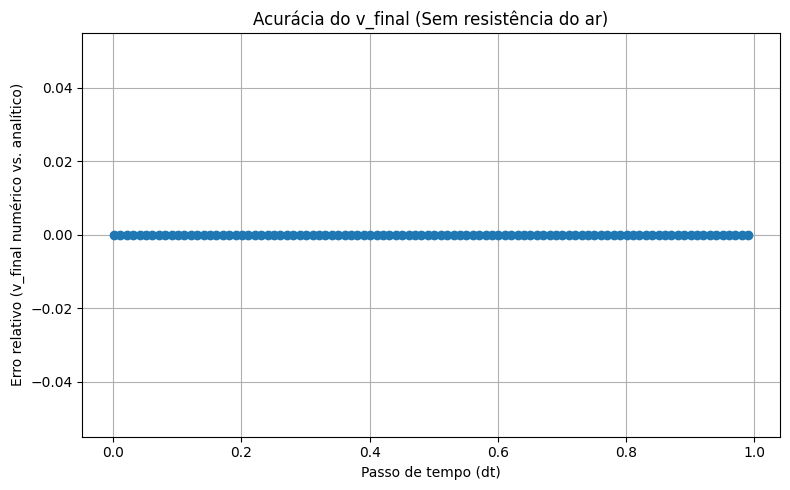

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos\acuracia_vfinal_sem_resistencia.png


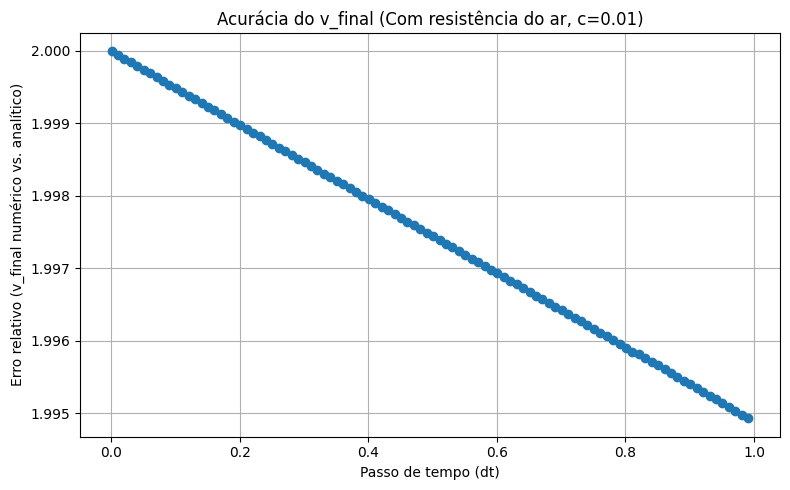

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos\acuracia_vfinal_com_resistencia_c_0_01.png


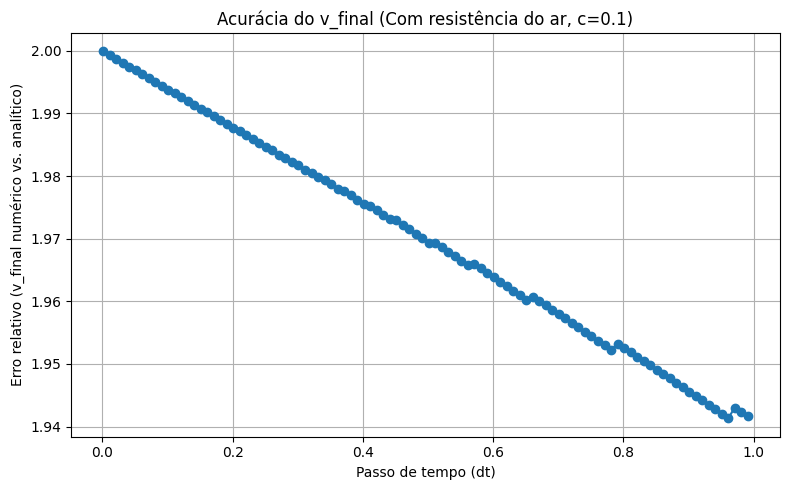

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos\acuracia_vfinal_com_resistencia_c_0_1.png


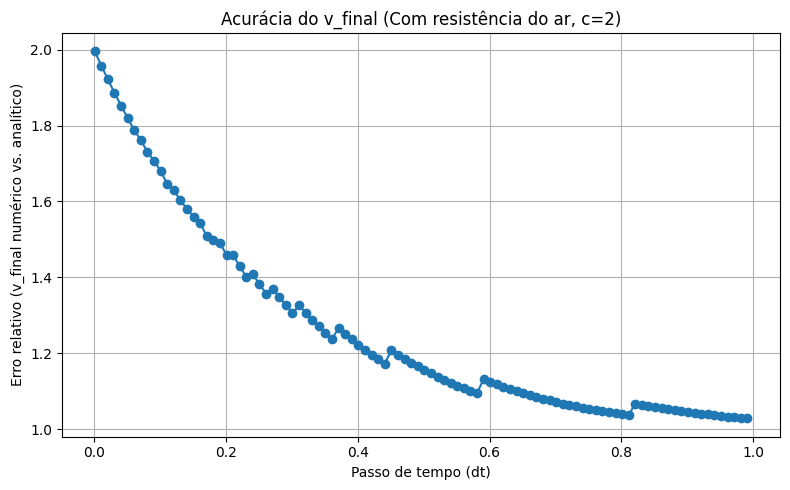

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos\acuracia_vfinal_com_resistencia_c_2.png


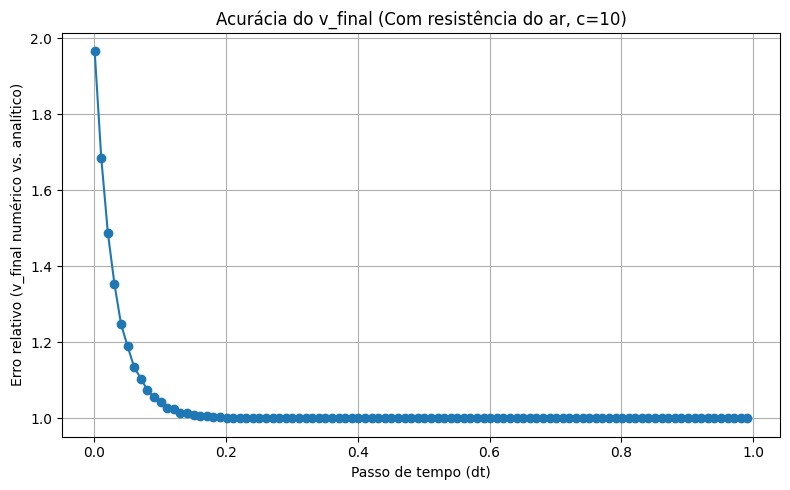

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos\acuracia_vfinal_com_resistencia_c_10.png


In [276]:
# Função para plotar o gráfico de erro relativo vs. dt lendo do CSV
import matplotlib.pyplot as plt
import pandas as pd

def plotar_acuracia_dt_csv(caminho_csv, titulo, nome_arquivo, graficos_dir):
    df = pd.read_csv(caminho_csv)
    dt_list = df['dt']
    erros = df['erro_relativo']
    plt.figure(figsize=(8,5))
    plt.plot(dt_list, erros, marker='o', linestyle='-', color='tab:blue')
    plt.xlabel('Passo de tempo (dt)')
    plt.ylabel('Erro relativo (v_final numérico vs. analítico)')
    plt.title(titulo)
    plt.grid(True)
    plt.tight_layout()
    caminho = graficos_dir / nome_arquivo
    plt.savefig(caminho)
    plt.show()
    print(f'Gráfico salvo em: {caminho}')

# Gráfico para queda livre sem resistência
titulo_sem = 'Acurácia do v_final (Sem resistência do ar)'
nome_grafico_sem = 'acuracia_vfinal_sem_resistencia.png'
csv_sem = dados_dir / 'acuracia_sem_resistencia.csv'
plotar_acuracia_dt_csv(csv_sem, titulo_sem, nome_grafico_sem, graficos_dir)

# Gráficos para queda livre com resistência para cada c
c_list = [0.01, 0.1, 2, 10]
for c in c_list:
    titulo_com = f'Acurácia do v_final (Com resistência do ar, c={c})'
    nome_grafico_com = f'acuracia_vfinal_com_resistencia_c_{str(c).replace(".", "_")}.png'
    csv_com = dados_dir / f'acuracia_com_resistencia_c_{str(c).replace(".", "_")}.csv'
    plotar_acuracia_dt_csv(csv_com, titulo_com, nome_grafico_com, graficos_dir)
